# Temporal Alignment Diagnostic: Prior vs Target Mel Spectrograms

Diagnose temporal misalignment between `prior_mel` and `target_mel` in the VocaloFlow training data.
Misalignment at stop consonant boundaries (P, T, K, B, D, G) is a suspected cause of over-smoothing during training.

**Three-panel view per sample:**
1. Prior mel spectrogram (resampled to target length, as the dataloader does)
2. Target mel spectrogram
3. Difference (target - prior) with diverging colormap centered at 0

**What to look for in the difference plot:**
- Small-scale noise, no structure → alignment is fine
- **Dipole patterns** (bright +/- bands adjacent at onsets) → temporal misalignment
- Large uniform bright regions offset in time → substantial phoneme-level misalignment

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import math
import re
from pathlib import Path

# ── Mel normalization constants (SoulX-Singer z-score) ──
MEL_MEAN = -4.92
MEL_VAR = 8.14
FRAME_SEC = 0.02  # hop=480, sr=24000 => 20ms per frame

# ── Configurable parameters ──
DATA_ROOT = Path("../Data/Rachie")
MANIFEST_PATH = DATA_ROOT / "manifest.csv"
DTW_COST_THRESHOLD = 60.0  # only inspect samples within this DTW cost
N_SAMPLES = 10
RANDOM_SEED = 42

# ARPAbet stop consonants — produce visible vertical bursts in spectrograms
STOP_CONSONANTS = {"P", "T", "K", "B", "D", "G"}


def pad_to_match(prior_mel, target_mel):
    """Zero-pad the shorter mel to match the longer one's length.
    
    Returns (prior_mel, target_mel, T) where both are (T, 128).
    """
    T_prior, T_target = prior_mel.shape[0], target_mel.shape[0]
    T = max(T_prior, T_target)
    if T_prior < T:
        prior_mel = np.pad(prior_mel, ((0, T - T_prior), (0, 0)))
    if T_target < T:
        target_mel = np.pad(target_mel, ((0, T - T_target), (0, 0)))
    return prior_mel, target_mel, T


def denormalize_mel(mel):
    """Reverse z-score: mel * sqrt(var) + mean."""
    return mel * math.sqrt(MEL_VAR) + MEL_MEAN


def time_axis(n_frames):
    """Return time values in seconds for n_frames."""
    return np.arange(n_frames) * FRAME_SEC

## Load Manifest & Filter by DTW Cost

In [2]:
df = pd.read_csv(MANIFEST_PATH)
total = len(df)

# Drop rows with missing DTW cost, then filter by threshold
df = df.dropna(subset=["dtw_cost"])
df = df[df["dtw_cost"] <= DTW_COST_THRESHOLD]

print(f"Total rows in manifest: {total:,}")
print(f"After DTW cost <= {DTW_COST_THRESHOLD}: {len(df):,}")

Total rows in manifest: 64,938
After DTW cost <= 60.0: 35,725


## Filter for Stop Consonants

Parse ARPAbet phonemes from `music.json` and keep only chunks containing at least one stop consonant (P, T, K, B, D, G).

In [3]:
def get_phoneme_info(row):
    """Load music.json for a row and return (has_stop, phoneme_text_str).
    
    ARPAbet tokens look like 'en_D-R-AY1-V-IH0-NG'. We strip the 'xx_' prefix,
    split on '-', strip trailing stress digits, and check for stop consonants.
    """
    music_path = DATA_ROOT / row["prior_mel_path"].replace("prior_mel.npy", "music.json")
    try:
        with open(music_path) as f:
            music = json.load(f)
    except FileNotFoundError:
        return False, ""

    all_phoneme_text = []
    has_stop = False

    for note in music:
        phon_field = note.get("phoneme", "")
        all_phoneme_text.append(phon_field)
        # Each token: "en_D-R-AY1-V-IH0-NG" or "<SP>"
        for token in phon_field.split():
            if token.startswith("<"):
                continue
            # Strip language prefix (e.g. "en_")
            core = re.sub(r"^[a-z]{2}_", "", token)
            for phoneme in core.split("-"):
                # Strip stress digits: AY1 -> AY
                base = re.sub(r"\d+$", "", phoneme)
                if base in STOP_CONSONANTS:
                    has_stop = True

    return has_stop, " | ".join(all_phoneme_text)


# Apply filter (only to DTW-filtered set to avoid loading all 65k JSONs)
results = df.apply(get_phoneme_info, axis=1, result_type="expand")
df["has_stop"] = results[0]
df["phoneme_text"] = results[1]

filtered_df = df[df["has_stop"]].copy()
print(f"After stop consonant filter: {len(filtered_df):,} chunks")

After stop consonant filter: 29,777 chunks


## Sample Selection

In [4]:
samples = filtered_df.sample(n=min(N_SAMPLES, len(filtered_df)), random_state=RANDOM_SEED)
print(f"Selected {len(samples)} samples for visualization\n")
samples[["dali_id", "chunk_name", "dtw_cost", "phoneme_text"]]

Selected 10 samples for visualization



,dali_id,chunk_name,dtw_cost,phoneme_text
29146,1823c5ffdbde4d46957287462bc2515a,line_23,51.2058,en_Y-UW1 en_N-OW1 en_IH1-T en_EY1-N-T en_IY1-Z...
47382,261be8966c2940d484f213f81fcf2a67,line_4,30.8214,en_D-UW1-B-IY0 <SP> en_D-AE1-M en_D-AE1-M
24088,1433c4d6e556458da2938249849c3c12,line_16,51.4498,en_IH1-F en_Y-UW1 en_HH-AE1-V en_AH0 en_V-AE1-...
54384,2b71de75e5fc4252819c0a9e671bc566,line_8,31.7416,en_IH1-Z en_DH-AE1-T en_AY1 en_L-ER1-N-D en_M-...
44498,240750ef1e4f4367b20e244673519752,line_26,28.3484,en_Y-UW1-L en_F-AY1-N-D en_AW1-T
47618,2626f67d69fc474fb07ca1a50b56b2f6,line_28,26.3298,en_L-AY1-K en_S-AH1-M-W-AH2-N <SP> en_T-UH1-K ...
27308,1683b94cf3f448ccaeb14eb83107e482,line_4,55.3257,en_K-AA1-Z en_W-IY1-R en_AA1-N en_F-AY1-ER0 <SP>
63348,3253a749d7a848039b13db5bed2a52be,line_62,34.2241,en_S-EH1-T en_M-IY1 en_F-R-IY1
52384,2a7e933e3c6045c9909953918de8991a,line_1,42.6413,en_AY1-M en_DH-AH0 en_F-ER1-S-T en_IH0-N en_L-...
11423,091c7128533c407588ee61c1cf9126ea,line_16,59.0883,en_S-T-AA1-P en_L-AH1-V-IH0-NG <SP> en_Y-UW1


## Per-Sample Alignment Diagnostic

Three panels side-by-side per sample, sharing the y-axis (mel bins):
1. **Prior mel** (zero-padded to match the longer of prior/target — no interpolation)
2. **Target mel**
3. **Difference** (target − prior), `RdBu_r` colormap centered at 0

Padding preserves the raw frame content so temporal offsets show up exactly as they are.

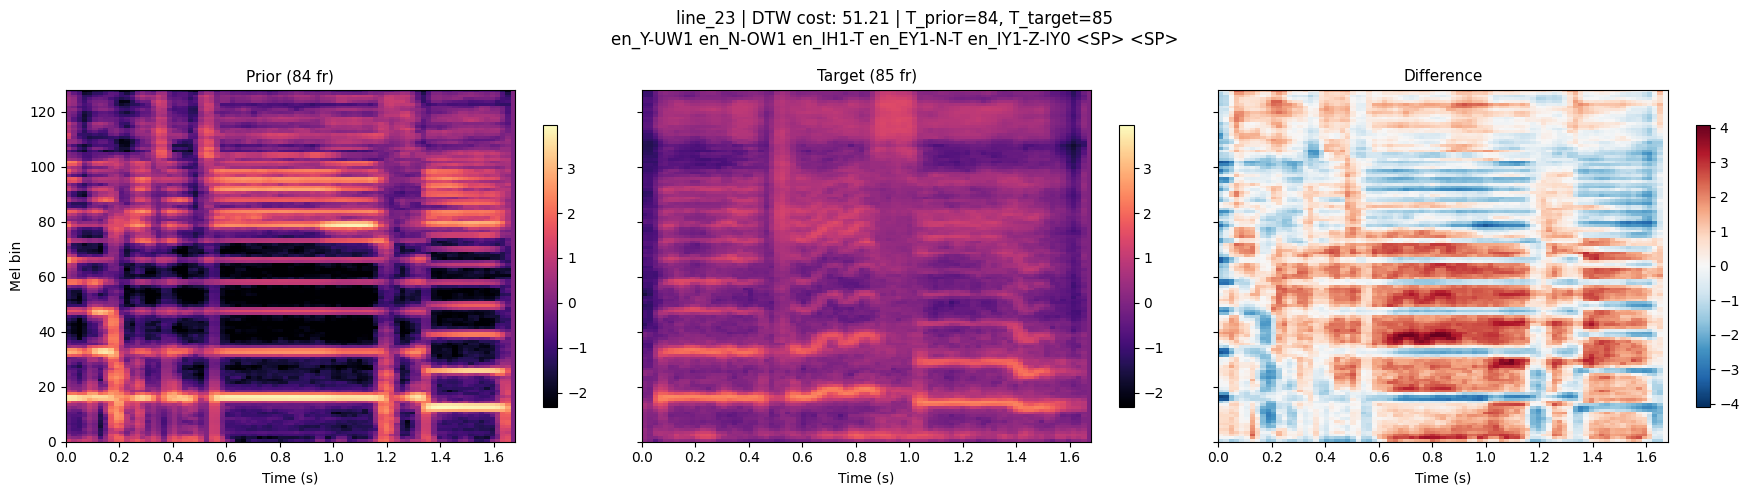

  mean |diff| = 1.1179,  max |diff| = 4.0806,  T_prior=84, T_target=85, ratio=0.988



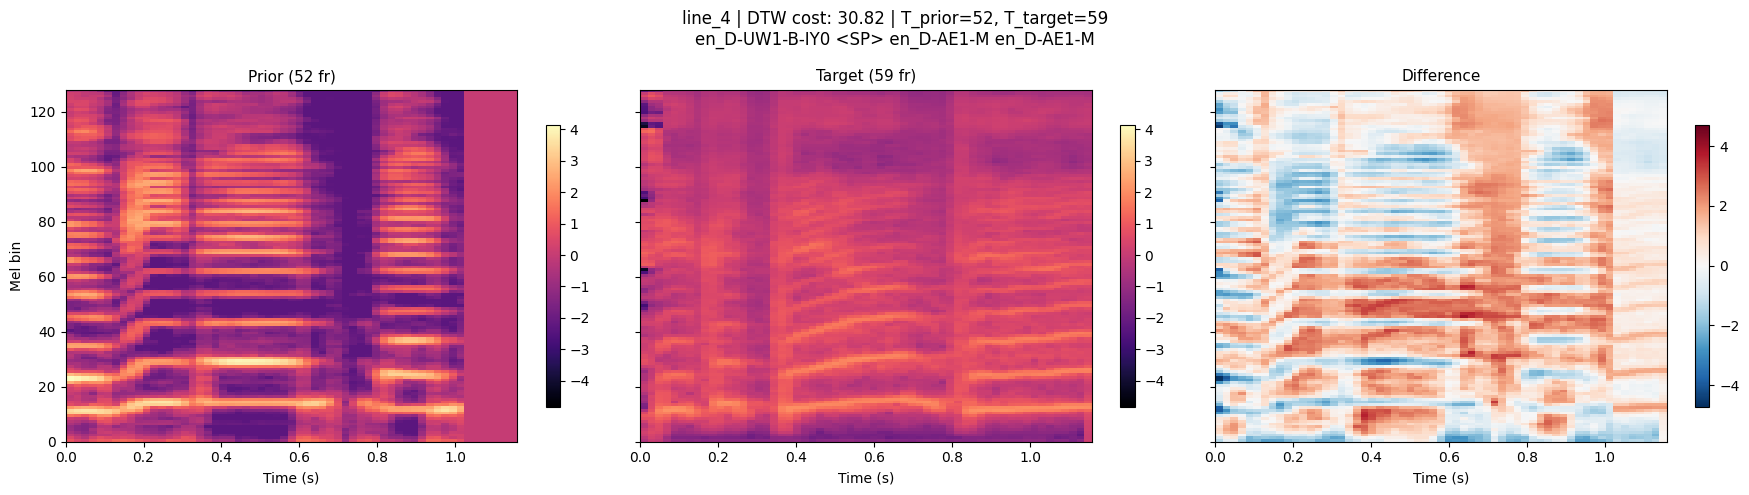

  mean |diff| = 1.2199,  max |diff| = 4.7168,  T_prior=52, T_target=59, ratio=0.881



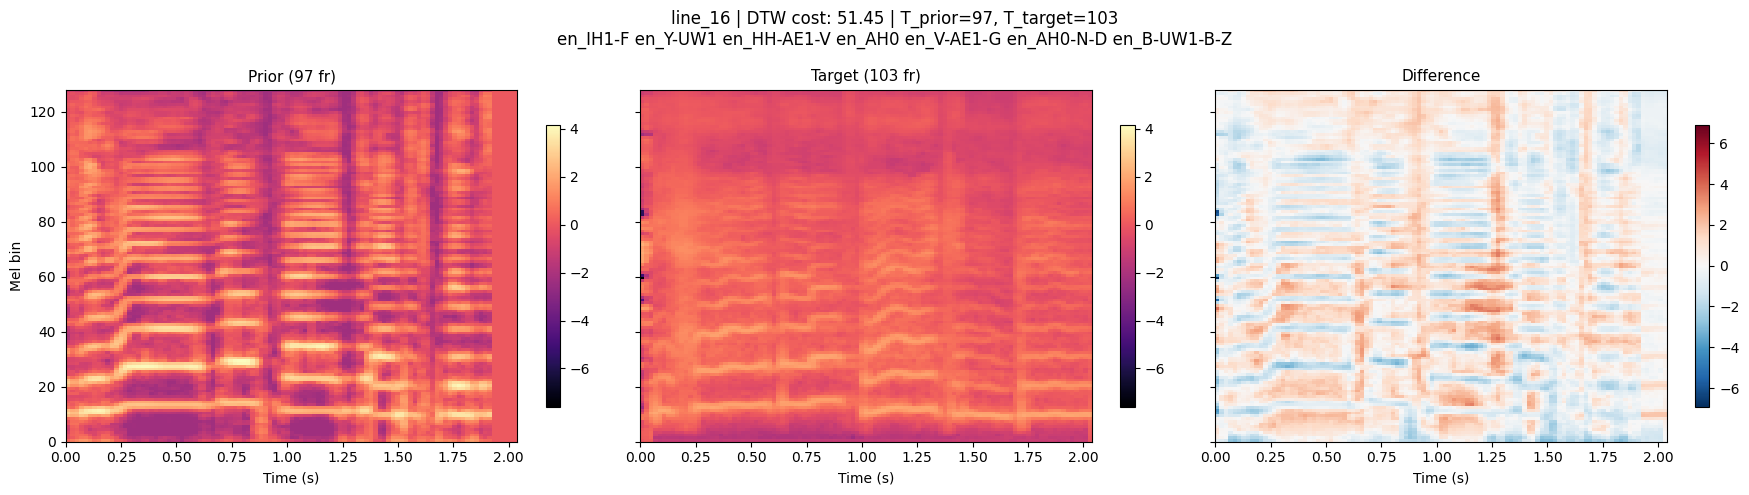

  mean |diff| = 0.9469,  max |diff| = 6.9040,  T_prior=97, T_target=103, ratio=0.942



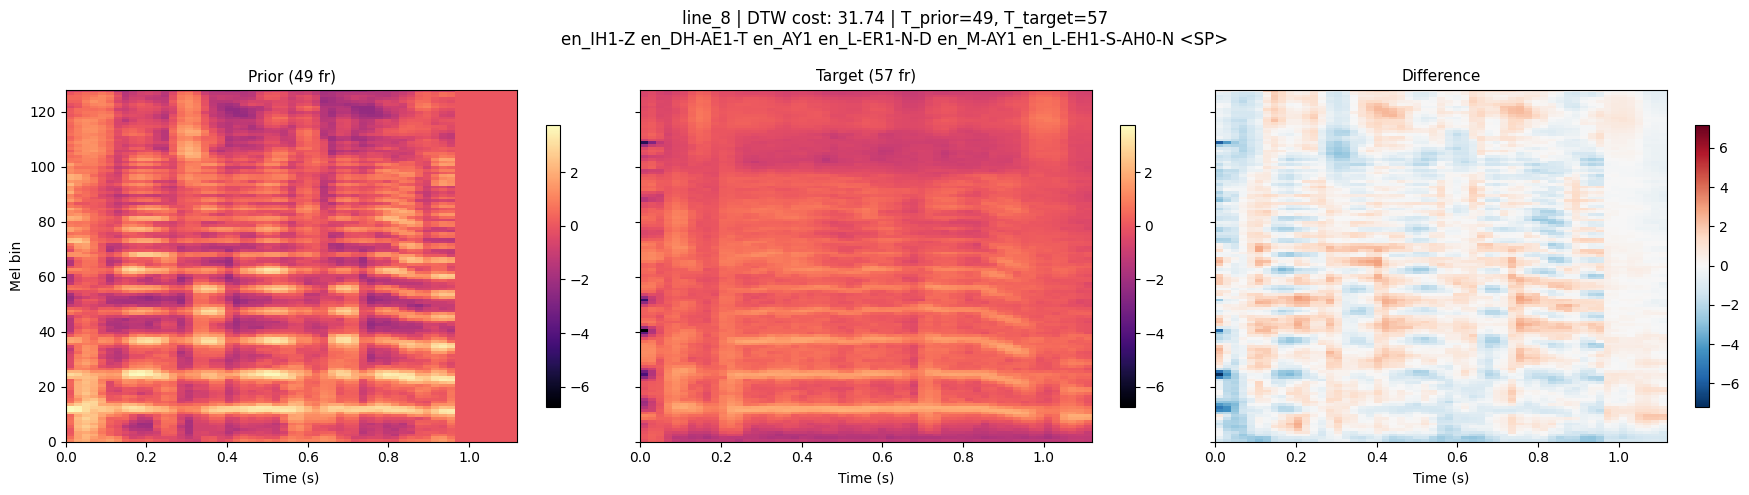

  mean |diff| = 0.8310,  max |diff| = 7.1757,  T_prior=49, T_target=57, ratio=0.860



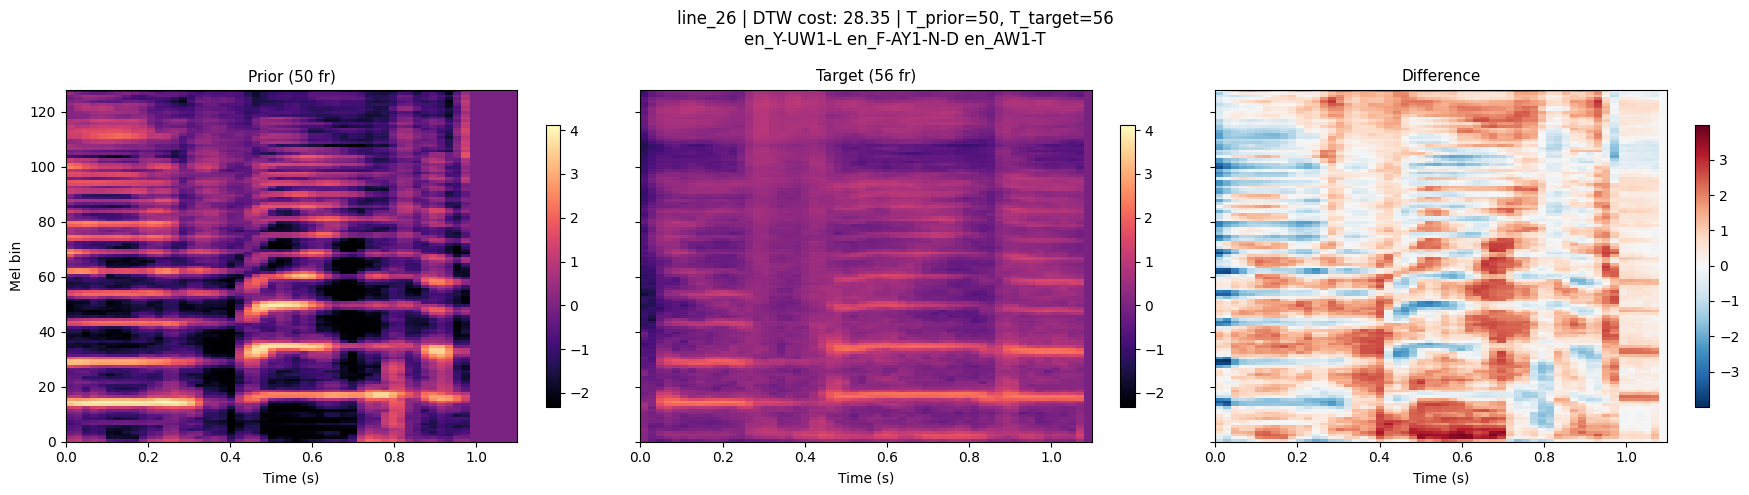

  mean |diff| = 1.0449,  max |diff| = 3.9904,  T_prior=50, T_target=56, ratio=0.893



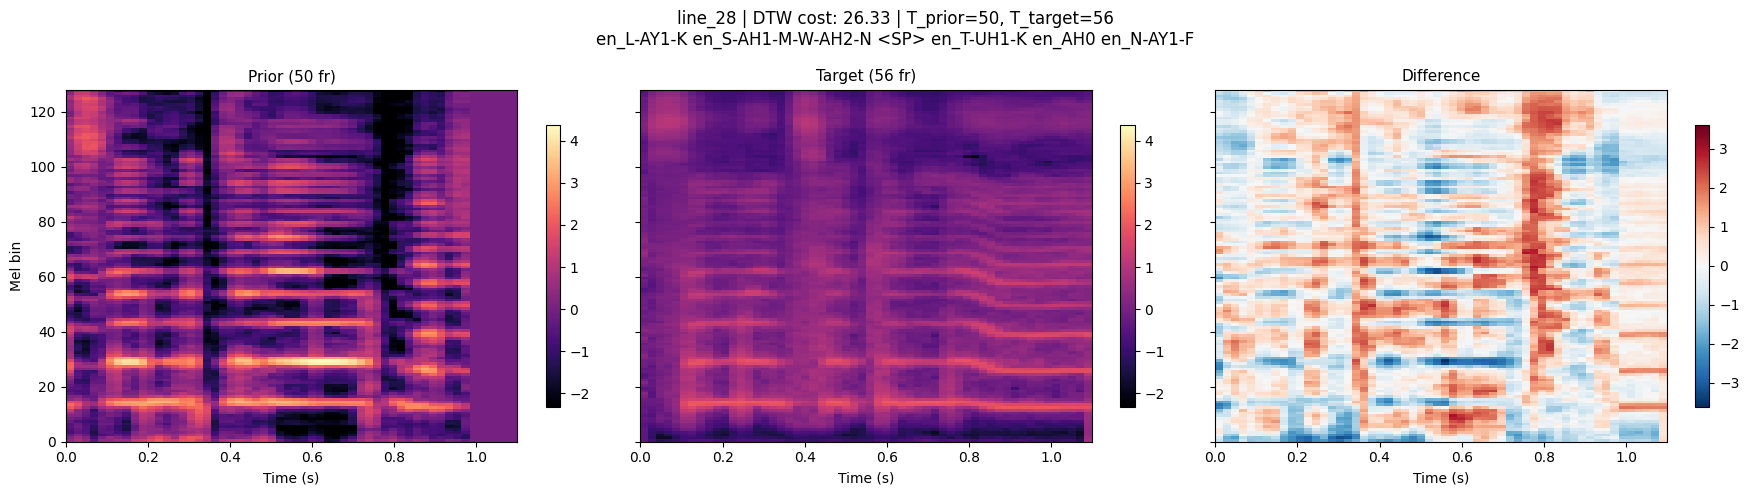

  mean |diff| = 0.8734,  max |diff| = 3.6157,  T_prior=50, T_target=56, ratio=0.893



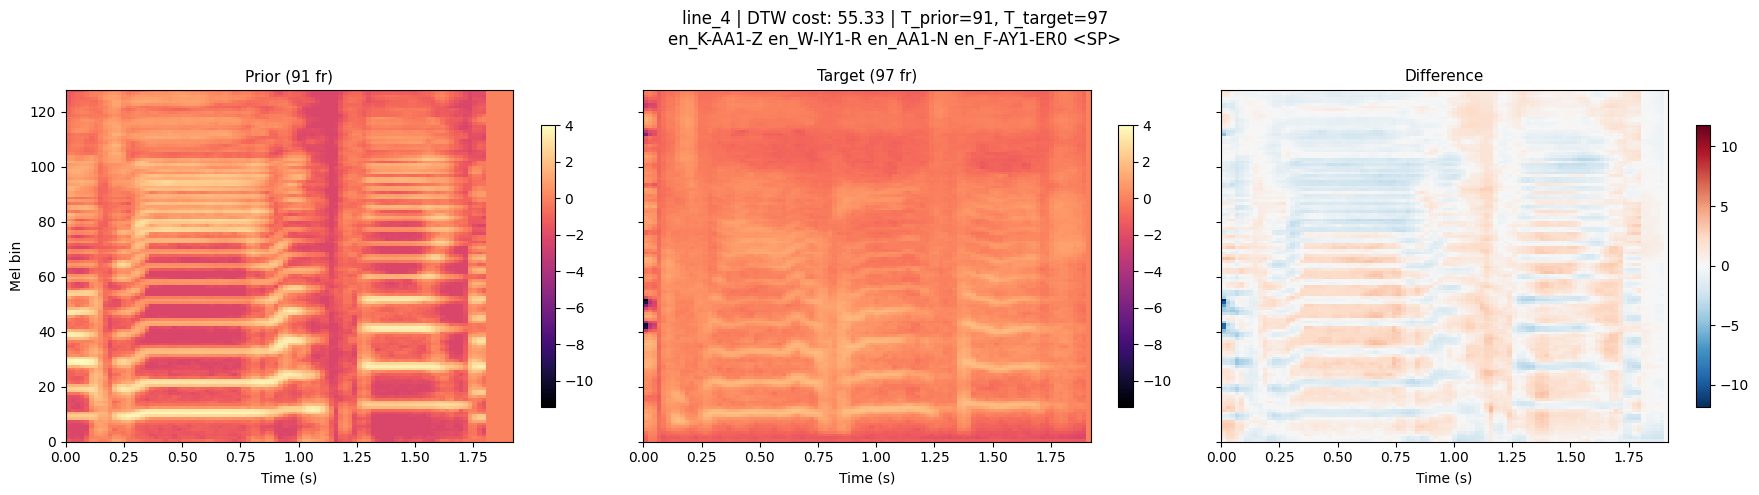

  mean |diff| = 1.1181,  max |diff| = 11.8094,  T_prior=91, T_target=97, ratio=0.938



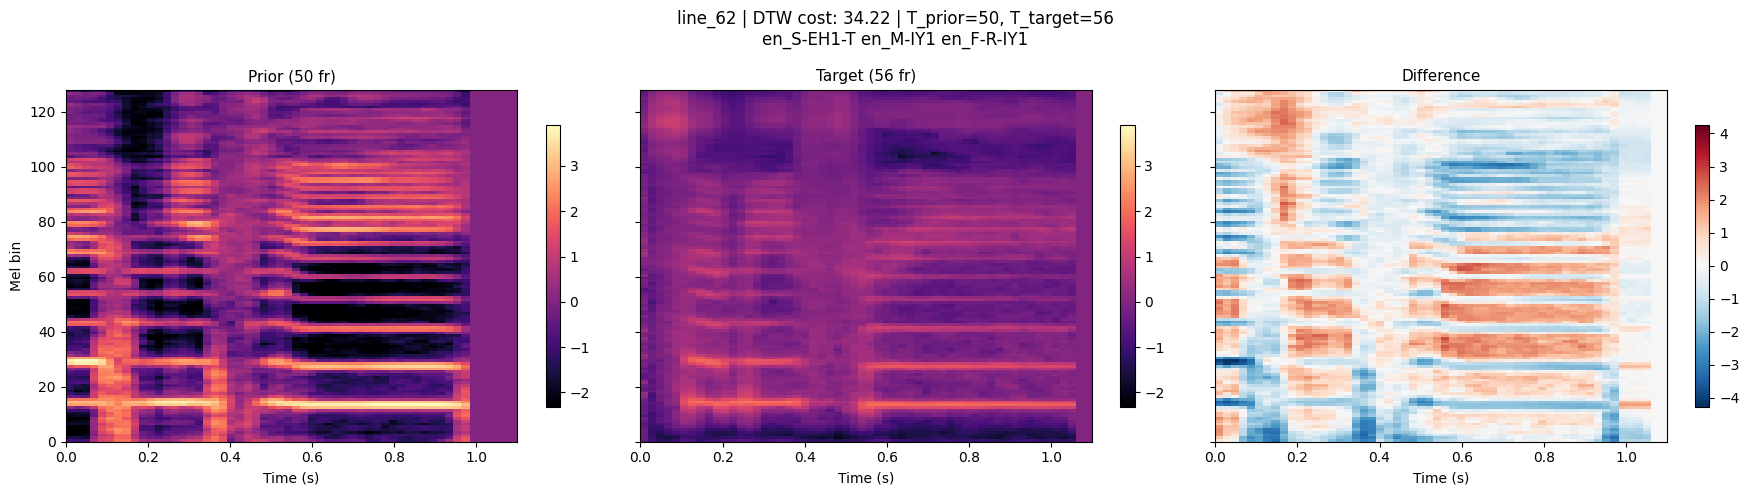

  mean |diff| = 0.9621,  max |diff| = 4.2608,  T_prior=50, T_target=56, ratio=0.893



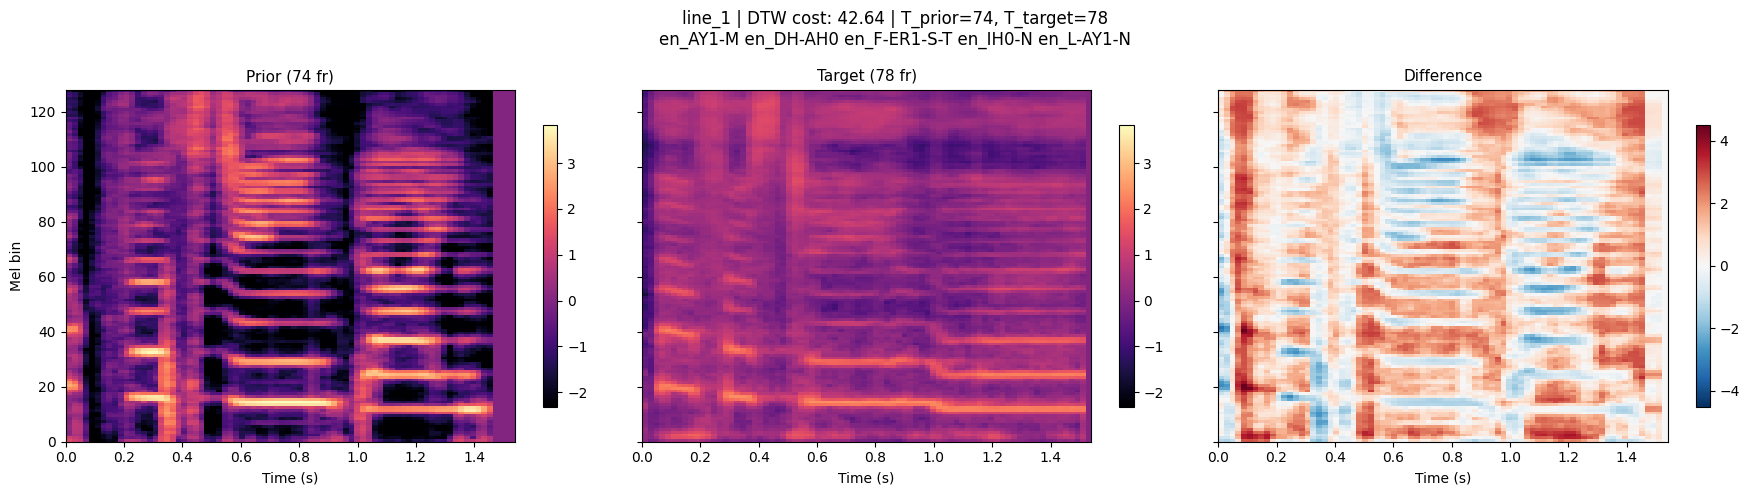

  mean |diff| = 1.1485,  max |diff| = 4.5056,  T_prior=74, T_target=78, ratio=0.949



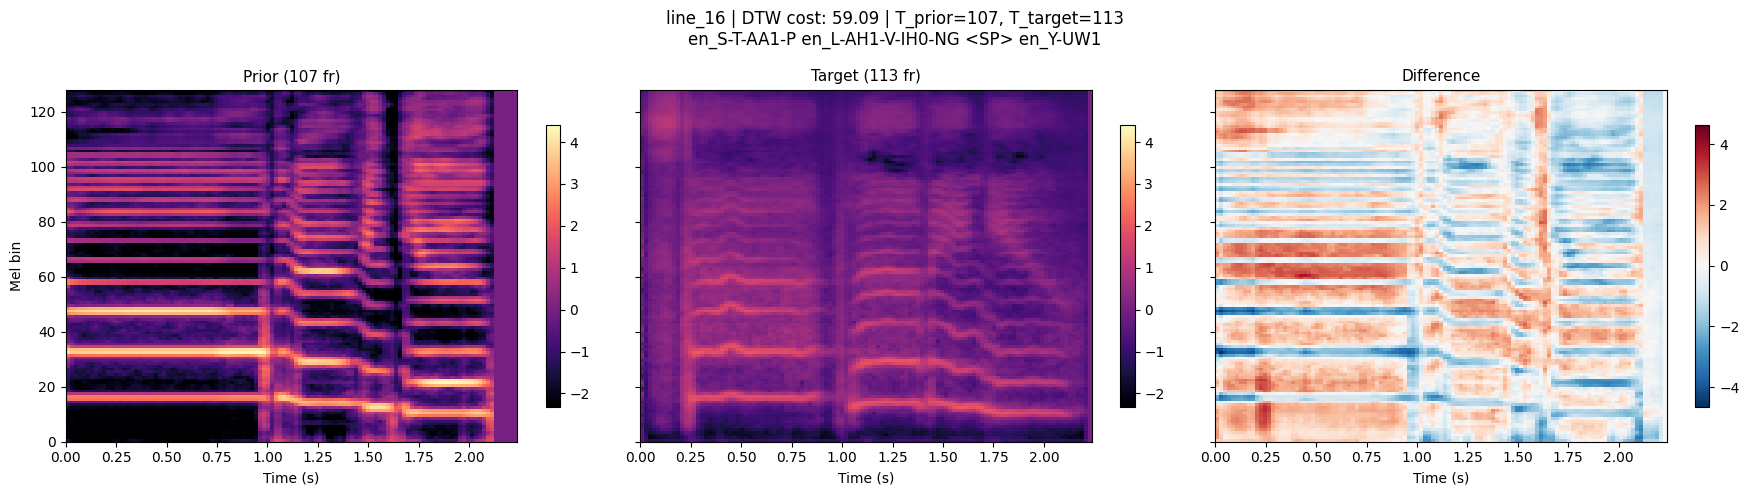

  mean |diff| = 1.0959,  max |diff| = 4.6344,  T_prior=107, T_target=113, ratio=0.947



In [ ]:
stats_rows = []

for _, row in samples.iterrows():
    prior_mel_raw = np.load(DATA_ROOT / row["prior_mel_path"])   # (T_prior, 128)
    target_mel_raw = np.load(DATA_ROOT / row["target_mel_path"]) # (T_target, 128)

    T_prior_orig = prior_mel_raw.shape[0]
    T_target_orig = target_mel_raw.shape[0]

    # Zero-pad shorter to match longer (preserves raw frame content)
    prior_mel, target_mel, T = pad_to_match(prior_mel_raw, target_mel_raw)

    diff = target_mel - prior_mel
    t = time_axis(T)

    # Shared color scale for prior & target
    vmin = min(prior_mel.min(), target_mel.min())
    vmax = max(prior_mel.max(), target_mel.max())
    # Symmetric scale for difference
    vlim = np.abs(diff).max()

    # ── Three panels side-by-side ──
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    panels = [
        (axes[0], prior_mel, f"Prior ({T_prior_orig} fr)",
         "magma", vmin, vmax),
        (axes[1], target_mel, f"Target ({T_target_orig} fr)",
         "magma", vmin, vmax),
        (axes[2], diff, "Difference",
         "RdBu_r", -vlim, vlim),
    ]

    for ax, data, title, cmap, lo, hi in panels:
        im = ax.imshow(
            data.T, origin="lower", aspect="auto",
            cmap=cmap, vmin=lo, vmax=hi,
            extent=[t[0], t[-1], 0, 128],
        )
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Time (s)")
        fig.colorbar(im, ax=ax, shrink=0.8)

    axes[0].set_ylabel("Mel bin")

    phon_display = row["phoneme_text"][:120]
    fig.suptitle(
        f"{row['chunk_name']} | DTW cost: {row['dtw_cost']:.2f} | "
        f"T_prior={T_prior_orig}, T_target={T_target_orig}\n{phon_display}",
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()

    # Stats over the overlapping region only (ignore padding)
    T_overlap = min(T_prior_orig, T_target_orig)
    diff_overlap = target_mel_raw[:T_overlap] - prior_mel_raw[:T_overlap]
    mean_abs = np.abs(diff_overlap).mean()
    max_abs = np.abs(diff_overlap).max()
    ratio = T_prior_orig / T_target_orig
    print(f"  mean |diff| = {mean_abs:.4f},  max |diff| = {max_abs:.4f},  "
          f"T_prior={T_prior_orig}, T_target={T_target_orig}, ratio={ratio:.3f}\n")

    stats_rows.append({
        "chunk_name": row["chunk_name"],
        "dali_id": row["dali_id"],
        "dtw_cost": row["dtw_cost"],
        "mean_abs_diff": mean_abs,
        "max_abs_diff": max_abs,
        "T_prior": T_prior_orig,
        "T_target": T_target_orig,
        "time_ratio": ratio,
    })

## Aggregate Statistics

In [6]:
stats_df = pd.DataFrame(stats_rows)
stats_df

,chunk_name,dali_id,dtw_cost,mean_abs_diff,max_abs_diff,T_prior,T_target,time_ratio
0,line_23,1823c5ffdbde4d46957287462bc2515a,51.2058,1.117852,4.080588,84,85,0.988235
1,line_4,261be8966c2940d484f213f81fcf2a67,30.8214,1.219880,4.716839,52,59,0.881356
2,line_16,1433c4d6e556458da2938249849c3c12,51.4498,0.946899,6.903970,97,103,0.941748
3,line_8,2b71de75e5fc4252819c0a9e671bc566,31.7416,0.830977,7.175708,49,57,0.859649
4,line_26,240750ef1e4f4367b20e244673519752,28.3484,1.044855,3.990370,50,56,0.892857
5,line_28,2626f67d69fc474fb07ca1a50b56b2f6,26.3298,0.873352,3.615669,50,56,0.892857
6,line_4,1683b94cf3f448ccaeb14eb83107e482,55.3257,1.118125,11.809419,91,97,0.938144
7,line_62,3253a749d7a848039b13db5bed2a52be,34.2241,0.962070,4.260817,50,56,0.892857
8,line_1,2a7e933e3c6045c9909953918de8991a,42.6413,1.148479,4.505568,74,78,0.948718
9,line_16,091c7128533c407588ee61c1cf9126ea,59.0883,1.095919,4.634426,107,113,0.946903


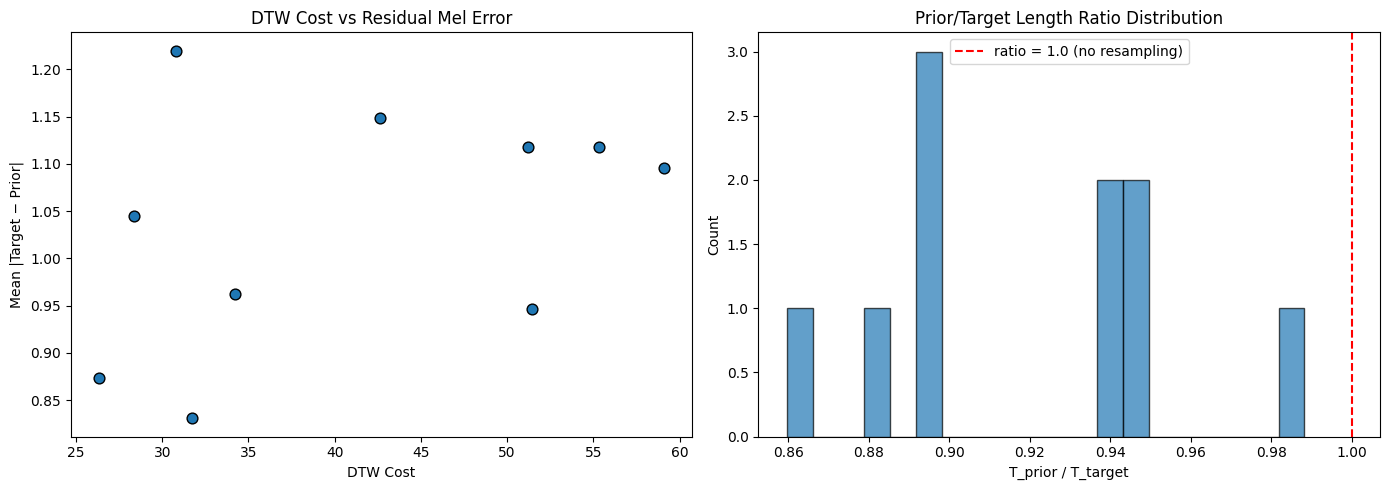

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DTW cost vs mean absolute difference
axes[0].scatter(stats_df["dtw_cost"], stats_df["mean_abs_diff"], s=60, edgecolors="k")
axes[0].set_xlabel("DTW Cost")
axes[0].set_ylabel("Mean |Target − Prior|")
axes[0].set_title("DTW Cost vs Residual Mel Error")

# Time ratio histogram
axes[1].hist(stats_df["time_ratio"], bins=20, edgecolor="k", alpha=0.7)
axes[1].axvline(1.0, color="red", linestyle="--", label="ratio = 1.0 (no resampling)")
axes[1].set_xlabel("T_prior / T_target")
axes[1].set_ylabel("Count")
axes[1].set_title("Prior/Target Length Ratio Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()